<a href="https://colab.research.google.com/github/dheerajnalla09/AIML/blob/main/Market_Basket_Analysis.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# Market Basket Analysis: Apriori, FP-Growth, ECLAT

**Goal:** Learn how to perform Market Basket Analysis (association rule mining) using Apriori, FP-Growth, and ECLAT. This notebook includes preprocessing, EDA, frequent itemset mining, association rule generation, predictive evaluation of rules, algorithm comparison (runtime / results), and recommendations. Each cell includes detailed explanations of inputs and expected outputs.

## 1) Imports

This cell imports modules used in the notebook. Explanations included as comments.

In [ ]:
!pip install mlxtend


In [ ]:

# Standard imports
import time
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from mlxtend.frequent_patterns import apriori, association_rules


# Frequent pattern mining and utilities
from mlxtend.frequent_patterns import apriori, fpgrowth, association_rules
from mlxtend.preprocessing import TransactionEncoder

# scikit-learn helpers for evaluation
from sklearn.model_selection import train_test_split

# Suppress warnings for clarity
import warnings
warnings.filterwarnings('ignore')

sns.set(style='whitegrid')
print('Imports completed.')


Imports completed.


## 2) Load dataset

Input: place your bakery CSV at `/mnt/data/Bakery.csv` (one-row-per-item or transaction-list format). The code below attempts to load and preview the file.

Output: DataFrame head and column listing.

In [ ]:

import os
path = r"C:\Users\admin\Documents\DS Class\ML\Unsupervised\Market basket\Bakery.csv"
if os.path.exists(path):
    df_raw = pd.read_csv(path)
    print('Loaded', path, 'shape:', df_raw.shape)
    display(df_raw.head())
    print('\nColumns:', df_raw.columns.tolist())
else:
    df_raw = None
    print('File not found at', path, '. The notebook includes a synthetic fallback later.')


Loaded C:\Users\admin\Documents\DS Class\ML\Unsupervised\Market basket\Bakery.csv shape: (20507, 5)


,TransactionNo,Items,DateTime,Daypart,DayType
0,1,Bread,2016-10-30 09:58:11,Morning,Weekend
1,2,Scandinavian,2016-10-30 10:05:34,Morning,Weekend
2,2,Scandinavian,2016-10-30 10:05:34,Morning,Weekend
3,3,Hot chocolate,2016-10-30 10:07:57,Morning,Weekend
4,3,Jam,2016-10-30 10:07:57,Morning,Weekend



Columns: ['TransactionNo', 'Items', 'DateTime', 'Daypart', 'DayType']


In [ ]:
df_raw = pd.DataFrame(df_raw)

print(df_raw.head())

   TransactionNo          Items             DateTime  Daypart  DayType
0              1          Bread  2016-10-30 09:58:11  Morning  Weekend
1              2   Scandinavian  2016-10-30 10:05:34  Morning  Weekend
2              2   Scandinavian  2016-10-30 10:05:34  Morning  Weekend
3              3  Hot chocolate  2016-10-30 10:07:57  Morning  Weekend
4              3            Jam  2016-10-30 10:07:57  Morning  Weekend


## 3) Transactions creation (group rows into lists)

Convert `df_raw` (long format) into `transactions` (list of lists). The code auto-detects common column names such as `InvoiceNo/OrderID` and `Item/Description`. If not found, it creates a synthetic dataset for demonstration.

Output: `transactions` list and `basket` one-hot DataFrame.

In [ ]:

def create_transactions_from_df(df):
    tx_cols = [c for c in df.columns if any(k in c.lower() for k in ['invoice','order','transaction','id','receipt'])]
    item_cols = [c for c in df.columns if any(k in c.lower() for k in ['item','product','description','name'])]

    if len(tx_cols) >= 1 and len(item_cols) >= 1:
        tx_col = tx_cols[0]
        item_col = item_cols[0]
        print('Using transaction column:', tx_col, 'and item column:', item_col)
        grouped = df.groupby(tx_col)[item_col].agg(list)
        transactions = [list(map(str.strip, [i for i in items if pd.notnull(i)])) for items in grouped.tolist()]
        return transactions, tx_col, item_col
    else:
        print('Could not auto-detect transaction/item columns. Generating synthetic transactions.')
        rng = np.random.RandomState(42)
        items = ['bread','milk','coffee','cake','sandwich','juice','tea','butter','jam','cookie']
        transactions = []
        for _ in range(500):
            k = rng.randint(1,5)
            transactions.append(list(rng.choice(items, size=k, replace=False)))
        return transactions, None, None

if df_raw is not None:
    transactions, tx_col, item_col = create_transactions_from_df(df_raw)
else:
    transactions, tx_col, item_col = create_transactions_from_df(pd.DataFrame())

print('Number of transactions:', len(transactions))
print('Example transactions (first 5):', transactions[:5])

# Transform to one-hot encoded basket DataFrame
from mlxtend.preprocessing import TransactionEncoder
te = TransactionEncoder()
te_ary = te.fit(transactions).transform(transactions)
basket = pd.DataFrame(te_ary, columns=te.columns_)
print('Basket shape (transactions x items):', basket.shape)
display(basket.head())


Using transaction column: TransactionNo and item column: Items
Number of transactions: 9465
Example transactions (first 5): [['Bread'], ['Scandinavian', 'Scandinavian'], ['Hot chocolate', 'Jam', 'Cookies'], ['Muffin'], ['Coffee', 'Pastry', 'Bread']]
Basket shape (transactions x items): (9465, 94)


,Adjustment,Afternoon with the baker,Alfajores,Argentina Night,Art Tray,Bacon,Baguette,Bakewell,Bare Popcorn,Basket,...,The BART,The Nomad,Tiffin,Toast,Truffles,Tshirt,Valentine's card,Vegan Feast,Vegan mincepie,Victorian Sponge
0,False,False,False,False,False,False,False,False,False,False,...,False,False,False,False,False,False,False,False,False,False
1,False,False,False,False,False,False,False,False,False,False,...,False,False,False,False,False,False,False,False,False,False
2,False,False,False,False,False,False,False,False,False,False,...,False,False,False,False,False,False,False,False,False,False
3,False,False,False,False,False,False,False,False,False,False,...,False,False,False,False,False,False,False,False,False,False
4,False,False,False,False,False,False,False,False,False,False,...,False,False,False,False,False,False,False,False,False,False


## 4) EDA on transactions

This cell computes item frequencies, top items, and basket size distribution.

Output: `item_freq` DataFrame, bar chart for top items, histogram of items-per-transaction.

,item,count,support
0,Coffee,4528,0.478394
1,Bread,3097,0.327205
2,Tea,1350,0.142631
3,Cake,983,0.103856
4,Pastry,815,0.086107
5,Sandwich,680,0.071844
6,Medialuna,585,0.061807
7,Hot chocolate,552,0.058320
8,Cookies,515,0.054411
9,Brownie,379,0.040042


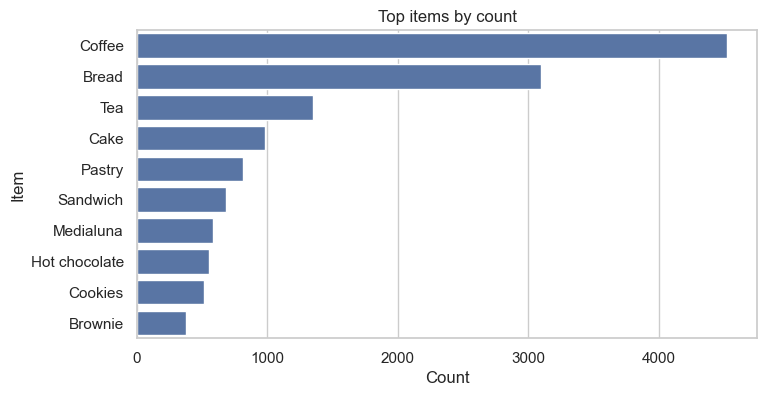

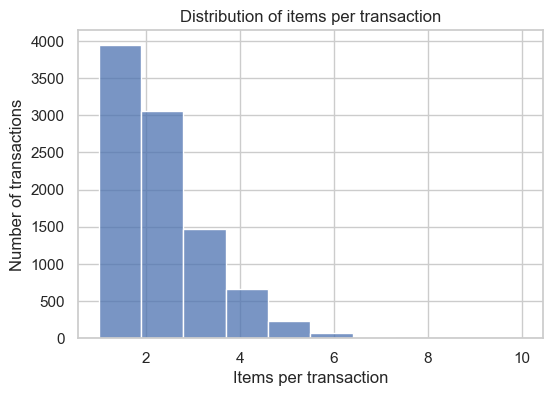

In [ ]:

# Frequency of each item (absolute and relative)
item_counts = basket.sum().sort_values(ascending=False)
item_freq = pd.DataFrame({'item': item_counts.index, 'count': item_counts.values, 'support': item_counts.values / len(basket)})
display(item_freq.head(20))

# Plot top 10 items
topk = 10
plt.figure(figsize=(8,4))
sns.barplot(x='count', y='item', data=item_freq.head(topk))
plt.title('Top items by count')
plt.xlabel('Count'); plt.ylabel('Item')
plt.show()

# Basket size distribution (items per transaction)
basket_size = basket.sum(axis=1)
plt.figure(figsize=(6,4))
sns.histplot(basket_size, bins=10, kde=False)
plt.title('Distribution of items per transaction')
plt.xlabel('Items per transaction'); plt.ylabel('Number of transactions')
plt.show()


## 5) Apriori frequent itemsets

Input parameters: `min_support` (e.g. 0.01). Output: `frequent_apriori` DataFrame with `itemsets` and `support`.

Notes: Apriori is level-wise candidate-generation; can be slow for large datasets.

In [ ]:

from time import time
min_support = 0.01

t0 = time()
frequent_apriori = apriori(basket, min_support=min_support, use_colnames=True)
t1 = time()
print('Apriori found', frequent_apriori.shape[0], 'frequent itemsets in %.2f seconds' % (t1-t0))
display(frequent_apriori.sort_values('support', ascending=False).head(20))


Apriori found 61 frequent itemsets in 0.06 seconds


,support,itemsets
6,0.478394,(Coffee)
2,0.327205,(Bread)
26,0.142631,(Tea)
4,0.103856,(Cake)
34,0.090016,"(Bread, Coffee)"
19,0.086107,(Pastry)
21,0.071844,(Sandwich)
16,0.061807,(Medialuna)
12,0.058320,(Hot chocolate)
42,0.054728,"(Cake, Coffee)"


## 6) FP-Growth frequent itemsets

Input parameters: `min_support`. Output: `frequent_fpg` DataFrame.

Notes: FP-Growth compresses transactions into an FP-tree and avoids candidate enumeration; often faster and preferred.

In [ ]:

t0 = time()
frequent_fpg = fpgrowth(basket, min_support=min_support, use_colnames=True)
t1 = time()
print('FP-Growth found', frequent_fpg.shape[0], 'frequent itemsets in %.2f seconds' % (t1-t0))
display(frequent_fpg.sort_values('support', ascending=False).head(20))


FP-Growth found 61 frequent itemsets in 0.80 seconds


,support,itemsets
6,0.478394,(Coffee)
0,0.327205,(Bread)
9,0.142631,(Tea)
16,0.103856,(Cake)
30,0.090016,"(Bread, Coffee)"
7,0.086107,(Pastry)
18,0.071844,(Sandwich)
8,0.061807,(Medialuna)
2,0.058320,(Hot chocolate)
46,0.054728,"(Cake, Coffee)"


## 7) ECLAT (vertical format) implementation

This is a teaching implementation of ECLAT using vertical tidset intersections. Input: `basket` and `min_support`. Output: `frequent_eclat` DataFrame.

In [ ]:

from collections import defaultdict
def eclat_vertical(basket, min_support=0.01):
    # Vertical representation: item -> set(transaction indices)
    item_tid = {item: set(basket.index[basket[item]].tolist()) for item in basket.columns}
    min_count = int(min_support * len(basket))
    # Filter infrequent single items
    item_tid = {item: tids for item, tids in item_tid.items() if len(tids) >= min_count}
    frequent_itemsets = []
    def recurse(prefix, items):
        while items:
            item, tids = items.pop()
            new_prefix = prefix + (item,)
            support_count = len(tids)
            frequent_itemsets.append((frozenset(new_prefix), support_count / len(basket)))
            new_items = []
            for (it2, tids2) in items:
                inter = tids & tids2
                if len(inter) >= min_count:
                    new_items.append((it2, inter))
            recurse(new_prefix, new_items)
    items = sorted(item_tid.items(), key=lambda x: len(x[1]), reverse=True)
    recurse(tuple(), items)
    return pd.DataFrame(frequent_itemsets, columns=['itemsets','support'])

t0 = time()
frequent_eclat = eclat_vertical(basket, min_support=min_support)
t1 = time()
print('ECLAT found', frequent_eclat.shape[0], 'frequent itemsets in %.2f seconds' % (t1-t0))
display(frequent_eclat.sort_values('support', ascending=False).head(20))


ECLAT found 61 frequent itemsets in 0.03 seconds


,itemsets,support
60,(Coffee),0.478394
58,(Bread),0.327205
55,(Tea),0.142631
49,(Cake),0.103856
59,"(Bread, Coffee)",0.090016
45,(Pastry),0.086107
41,(Sandwich),0.071844
38,(Medialuna),0.061807
34,(Hot chocolate),0.058320
54,"(Coffee, Cake)",0.054728


## 8) Generate association rules

Use `mlxtend.association_rules` to compute confidence, lift, leverage, conviction, etc. We compute rules from Apriori and FP-Growth results for comparison.

Input: frequent itemsets and `min_confidence`. Output: `rules_apriori` and `rules_fpg` DataFrames.

In [ ]:

min_confidence = 0.3

# Rules from Apriori
rules_apriori = association_rules(frequent_apriori, metric='confidence', min_threshold=min_confidence)
rules_apriori = rules_apriori.sort_values(['lift','confidence'], ascending=False).reset_index(drop=True)
print('Apriori generated', rules_apriori.shape[0], 'rules. Example:')
display(rules_apriori.head(10))

# Rules from FP-Growth
rules_fpg = association_rules(frequent_fpg, metric='confidence', min_threshold=min_confidence)
rules_fpg = rules_fpg.sort_values(['lift','confidence'], ascending=False).reset_index(drop=True)
print('FP-Growth generated', rules_fpg.shape[0], 'rules. Example:')
display(rules_fpg.head(10))


Apriori generated 19 rules. Example:


,antecedents,consequents,antecedent support,consequent support,support,confidence,lift,representativity,leverage,conviction,zhangs_metric,jaccard,certainty,kulczynski
0,(Toast),(Coffee),0.033597,0.478394,0.023666,0.704403,1.472431,1.0,0.007593,1.764582,0.332006,0.048464,0.433293,0.376936
1,(Spanish Brunch),(Coffee),0.018172,0.478394,0.010882,0.598837,1.251766,1.0,0.002189,1.300235,0.204851,0.022406,0.230908,0.310792
2,(Medialuna),(Coffee),0.061807,0.478394,0.035182,0.569231,1.189878,1.0,0.005614,1.210871,0.170091,0.069665,0.174148,0.321387
3,(Pastry),(Coffee),0.086107,0.478394,0.047544,0.552147,1.154168,1.0,0.006351,1.164682,0.146161,0.091968,0.141396,0.325764
4,(Alfajores),(Coffee),0.036344,0.478394,0.019651,0.540698,1.130235,1.0,0.002264,1.135648,0.119574,0.039693,0.119446,0.290888
5,(Juice),(Coffee),0.038563,0.478394,0.020602,0.534247,1.116750,1.0,0.002154,1.119919,0.108738,0.041507,0.107078,0.288656
6,(Sandwich),(Coffee),0.071844,0.478394,0.038246,0.532353,1.112792,1.0,0.003877,1.115384,0.109205,0.074701,0.103448,0.306150
7,(Cake),(Coffee),0.103856,0.478394,0.054728,0.526958,1.101515,1.0,0.005044,1.102664,0.102840,0.103745,0.093105,0.320679
8,(Scone),(Coffee),0.034548,0.478394,0.018067,0.522936,1.093107,1.0,0.001539,1.093366,0.088224,0.036507,0.085393,0.280350
9,(Cookies),(Coffee),0.054411,0.478394,0.028209,0.518447,1.083723,1.0,0.002179,1.083174,0.081700,0.055905,0.076787,0.288707


FP-Growth generated 19 rules. Example:


,antecedents,consequents,antecedent support,consequent support,support,confidence,lift,representativity,leverage,conviction,zhangs_metric,jaccard,certainty,kulczynski
0,(Toast),(Coffee),0.033597,0.478394,0.023666,0.704403,1.472431,1.0,0.007593,1.764582,0.332006,0.048464,0.433293,0.376936
1,(Spanish Brunch),(Coffee),0.018172,0.478394,0.010882,0.598837,1.251766,1.0,0.002189,1.300235,0.204851,0.022406,0.230908,0.310792
2,(Medialuna),(Coffee),0.061807,0.478394,0.035182,0.569231,1.189878,1.0,0.005614,1.210871,0.170091,0.069665,0.174148,0.321387
3,(Pastry),(Coffee),0.086107,0.478394,0.047544,0.552147,1.154168,1.0,0.006351,1.164682,0.146161,0.091968,0.141396,0.325764
4,(Alfajores),(Coffee),0.036344,0.478394,0.019651,0.540698,1.130235,1.0,0.002264,1.135648,0.119574,0.039693,0.119446,0.290888
5,(Juice),(Coffee),0.038563,0.478394,0.020602,0.534247,1.116750,1.0,0.002154,1.119919,0.108738,0.041507,0.107078,0.288656
6,(Sandwich),(Coffee),0.071844,0.478394,0.038246,0.532353,1.112792,1.0,0.003877,1.115384,0.109205,0.074701,0.103448,0.306150
7,(Cake),(Coffee),0.103856,0.478394,0.054728,0.526958,1.101515,1.0,0.005044,1.102664,0.102840,0.103745,0.093105,0.320679
8,(Scone),(Coffee),0.034548,0.478394,0.018067,0.522936,1.093107,1.0,0.001539,1.093366,0.088224,0.036507,0.085393,0.280350
9,(Cookies),(Coffee),0.054411,0.478394,0.028209,0.518447,1.083723,1.0,0.002179,1.083174,0.081700,0.055905,0.076787,0.288707


## 8.1 Filter & inspect top rules

We filter for single-item consequents for easier evaluation and present top rules sorted by lift and confidence.

In [ ]:

# Keep rules with single-item consequent for evaluation convenience
def filter_single_consequent(rules_df):
    return rules_df[rules_df['consequents'].apply(lambda x: len(x)==1)].copy()

rules_apriori_single = filter_single_consequent(rules_apriori)
rules_fpg_single = filter_single_consequent(rules_fpg)

print('Apriori single-consequent rules:', rules_apriori_single.shape[0])
print('FP-Growth single-consequent rules:', rules_fpg_single.shape[0])

# Show top 10 by lift (Apriori)
display(rules_apriori_single.sort_values('lift', ascending=False).head(10))


Apriori single-consequent rules: 19
FP-Growth single-consequent rules: 19


,antecedents,consequents,antecedent support,consequent support,support,confidence,lift,representativity,leverage,conviction,zhangs_metric,jaccard,certainty,kulczynski
0,(Toast),(Coffee),0.033597,0.478394,0.023666,0.704403,1.472431,1.0,0.007593,1.764582,0.332006,0.048464,0.433293,0.376936
1,(Spanish Brunch),(Coffee),0.018172,0.478394,0.010882,0.598837,1.251766,1.0,0.002189,1.300235,0.204851,0.022406,0.230908,0.310792
2,(Medialuna),(Coffee),0.061807,0.478394,0.035182,0.569231,1.189878,1.0,0.005614,1.210871,0.170091,0.069665,0.174148,0.321387
3,(Pastry),(Coffee),0.086107,0.478394,0.047544,0.552147,1.154168,1.0,0.006351,1.164682,0.146161,0.091968,0.141396,0.325764
4,(Alfajores),(Coffee),0.036344,0.478394,0.019651,0.540698,1.130235,1.0,0.002264,1.135648,0.119574,0.039693,0.119446,0.290888
5,(Juice),(Coffee),0.038563,0.478394,0.020602,0.534247,1.116750,1.0,0.002154,1.119919,0.108738,0.041507,0.107078,0.288656
6,(Sandwich),(Coffee),0.071844,0.478394,0.038246,0.532353,1.112792,1.0,0.003877,1.115384,0.109205,0.074701,0.103448,0.306150
7,(Cake),(Coffee),0.103856,0.478394,0.054728,0.526958,1.101515,1.0,0.005044,1.102664,0.102840,0.103745,0.093105,0.320679
8,(Scone),(Coffee),0.034548,0.478394,0.018067,0.522936,1.093107,1.0,0.001539,1.093366,0.088224,0.036507,0.085393,0.280350
9,(Cookies),(Coffee),0.054411,0.478394,0.028209,0.518447,1.083723,1.0,0.002179,1.083174,0.081700,0.055905,0.076787,0.288707


## 9) Predictive evaluation of rules on a holdout set

We split transactions into train/test, mine rules on train, and evaluate rules' predictive power on test by computing precision, recall, and F1 for each rule (treat antecedent as predictor for consequent).

Output: evaluation DataFrame for top rules.

In [ ]:

from sklearn.model_selection import train_test_split
from sklearn.metrics import precision_score, recall_score, f1_score

# Split transactions into train and test (list of lists)
train_tx, test_tx = train_test_split(transactions, test_size=0.3, random_state=42)
print('Train transactions:', len(train_tx), 'Test transactions:', len(test_tx))

def evaluate_rule_on_transactions(rule_antecedent, rule_consequent, test_transactions):
    y_true = []
    y_pred = []
    for tx in test_transactions:
        tx_set = set(tx)
        y_true.append(1 if rule_consequent.issubset(tx_set) else 0)
        y_pred.append(1 if rule_antecedent.issubset(tx_set) else 0)
    if sum(y_pred) == 0:
        prec = 0.0
    else:
        prec = precision_score(y_true, y_pred, zero_division=0)
    rec = recall_score(y_true, y_pred, zero_division=0)
    f1 = f1_score(y_true, y_pred, zero_division=0)
    return {'precision': prec, 'recall': rec, 'f1': f1, 'support_test': sum(y_true)/len(y_true)}

def evaluate_rules_dataframe(rules_df, top_n=20, test_transactions=None):
    rows = []
    for idx, row in rules_df.head(top_n).iterrows():
        antecedent = set(row['antecedents'])
        consequent = set(row['consequents'])
        metrics = evaluate_rule_on_transactions(antecedent, consequent, test_transactions)
        rows.append({
            'rule': f"{set(antecedent)} -> {set(consequent)}",
            'support': row['support'],
            'confidence': row['confidence'],
            'lift': row['lift'],
            'precision_test': metrics['precision'],
            'recall_test': metrics['recall'],
            'f1_test': metrics['f1'],
            'support_test': metrics['support_test']
        })
    return pd.DataFrame(rows)

eval_apriori = evaluate_rules_dataframe(rules_apriori_single, top_n=30, test_transactions=test_tx)
eval_fpg = evaluate_rules_dataframe(rules_fpg_single, top_n=30, test_transactions=test_tx)

print('Evaluation of top Apriori rules on holdout:')
display(eval_apriori.sort_values('f1_test', ascending=False).head(10))

print('Evaluation of top FP-Growth rules on holdout:')
display(eval_fpg.sort_values('f1_test', ascending=False).head(10))


Train transactions: 6625 Test transactions: 2840
Evaluation of top Apriori rules on holdout:


,rule,support,confidence,lift,precision_test,recall_test,f1_test,support_test
7,{'Cake'} -> {'Coffee'},0.054728,0.526958,1.101515,0.536667,0.116414,0.191325,0.486972
18,{'Tea'} -> {'Coffee'},0.049868,0.349630,0.730840,0.377088,0.114244,0.175361,0.486972
3,{'Pastry'} -> {'Coffee'},0.047544,0.552147,1.154168,0.527778,0.096168,0.162691,0.486972
11,{'Pastry'} -> {'Bread'},0.029160,0.338650,1.034977,0.353175,0.096216,0.151232,0.325704
6,{'Sandwich'} -> {'Coffee'},0.038246,0.532353,1.112792,0.535885,0.080983,0.140704,0.486972
2,{'Medialuna'} -> {'Coffee'},0.035182,0.569231,1.189878,0.556180,0.071584,0.126842,0.486972
10,{'Hot chocolate'} -> {'Coffee'},0.029583,0.507246,1.060311,0.500000,0.062184,0.110611,0.486972
9,{'Cookies'} -> {'Coffee'},0.028209,0.518447,1.083723,0.518293,0.061461,0.109890,0.486972
0,{'Toast'} -> {'Coffee'},0.023666,0.704403,1.472431,0.731481,0.057122,0.105969,0.486972
4,{'Alfajores'} -> {'Coffee'},0.019651,0.540698,1.130235,0.633663,0.046276,0.086253,0.486972


Evaluation of top FP-Growth rules on holdout:


,rule,support,confidence,lift,precision_test,recall_test,f1_test,support_test
7,{'Cake'} -> {'Coffee'},0.054728,0.526958,1.101515,0.536667,0.116414,0.191325,0.486972
18,{'Tea'} -> {'Coffee'},0.049868,0.349630,0.730840,0.377088,0.114244,0.175361,0.486972
3,{'Pastry'} -> {'Coffee'},0.047544,0.552147,1.154168,0.527778,0.096168,0.162691,0.486972
11,{'Pastry'} -> {'Bread'},0.029160,0.338650,1.034977,0.353175,0.096216,0.151232,0.325704
6,{'Sandwich'} -> {'Coffee'},0.038246,0.532353,1.112792,0.535885,0.080983,0.140704,0.486972
2,{'Medialuna'} -> {'Coffee'},0.035182,0.569231,1.189878,0.556180,0.071584,0.126842,0.486972
10,{'Hot chocolate'} -> {'Coffee'},0.029583,0.507246,1.060311,0.500000,0.062184,0.110611,0.486972
9,{'Cookies'} -> {'Coffee'},0.028209,0.518447,1.083723,0.518293,0.061461,0.109890,0.486972
0,{'Toast'} -> {'Coffee'},0.023666,0.704403,1.472431,0.731481,0.057122,0.105969,0.486972
4,{'Alfajores'} -> {'Coffee'},0.019651,0.540698,1.130235,0.633663,0.046276,0.086253,0.486972


## 10) Algorithm comparison: counts & runtimes

We compare Apriori, FP-Growth, and ECLAT by number of frequent itemsets discovered and number of rules generated (for Apriori/FP-Growth).

In [ ]:

comparison = {
    'algorithm': ['Apriori','FP-Growth'],
    'frequent_itemsets_count': [frequent_apriori.shape[0], frequent_fpg.shape[0]],
    'num_rules_generated': [rules_apriori.shape[0], rules_fpg.shape[0]]
}
comp_df = pd.DataFrame(comparison)
display(comp_df)


,algorithm,frequent_itemsets_count,num_rules_generated
0,Apriori,61,19
1,FP-Growth,61,19


## 11) Recommendations & best practices

- **FP-Growth**: preferred for larger datasets due to performance; no candidate generation.
- **Apriori**: educational and simple, good for small-medium datasets.
- **ECLAT**: vertical tidset approach; can be efficient for sparse data and when intersections are cheap.

**Evaluation tip:** Validate rules on a holdout set and use precision/recall to measure predictive usefulness. Tune `min_support` and `min_confidence` to control number of rules. Save top rules to CSV for business reporting.